# 🐼 Tema 6: Pandas - DataFrames, Lectura y Exportación

¡Bienvenido/a al corazón del Análisis de Datos en Python!

Hasta ahora hemos trabajado con estructuras nativas como listas y diccionarios. Sin embargo, en la vida real, los datos vienen en tablas masivas (como en Excel o SQL). **Pandas** es la librería estándar de la industria que nos permite leer, manipular, transformar y analizar estos datos tabulares de forma rápida y eficiente.

## 🚀 Contenido del Cuaderno

1. **Extracción e Indexación:** ¿Cómo navegar por los datos?
2. **Transformación de DataFrames:** Creación de nuevas variables y limpieza.
3. **Agregación de DataFrames:** Agrupando datos para obtener estadísticas.
4. **Visualización Básica:** Explorando datos gráficamente.
5. **Ejercicio Práctico 1:** Análisis estadístico del dataset Iris.
6. **Ejercicio Práctico 2:** Gráfico de dispersión.
7. **Nivel Pro:** Method Chaining (Encadenamiento de métodos) y gráficos orientados a objetos.

---
> **Instrucciones:** Ejecuta las celdas de código (Code) paso a paso. Asegúrate de tener instalada la librería ejecutando `pip install pandas matplotlib` en tu terminal si corres esto localmente.

## 1. Extracción, Indexación y Transformación



Un **DataFrame** es esencialmente una tabla bidimensional con etiquetas en las filas (índices) y en las columnas. 
* **Extracción e Indexación:** Es el proceso de seleccionar filas o columnas específicas (por ejemplo, "dame solo las ventas de enero"). Se utilizan métodos como `.loc[]` (por nombre) o `.iloc[]` (por posición), o simplemente corchetes `df['columna']`.
* **Transformación:** Implica modificar los datos existentes, ya sea creando nuevas columnas basadas en operaciones matemáticas, rellenando valores nulos o renombrando columnas.

In [1]:
# 💡 Ejemplo Básico: Creación y transformación de un DataFrame
import pandas as pd

# 1. Crear un DataFrame desde un diccionario
datos_tienda = {
    'Producto': ['Manzanas', 'Peras', 'Plátanos'],
    'Precio': [2.5, 3.0, 1.5],
    'Stock': [100, 50, 200]
}
df_tienda = pd.DataFrame(datos_tienda)

# 2. Extracción (Filtrar solo los que tienen stock mayor a 80)
productos_abundantes = df_tienda[df_tienda['Stock'] > 80]

# 3. Transformación (Crear una nueva columna)
df_tienda['Valor_Total'] = df_tienda['Precio'] * df_tienda['Stock']

print("--- DataFrame Transformado ---")
print(df_tienda)

--- DataFrame Transformado ---
   Producto  Precio  Stock  Valor_Total
0  Manzanas     2.5    100        250.0
1     Peras     3.0     50        150.0
2  Plátanos     1.5    200        300.0


## 2. Agregación y Visualización



* **Agregación:** Consiste en agrupar los datos por alguna categoría y luego aplicar una función matemática (suma, promedio, conteo) a esos grupos. En Pandas, la función mágica para esto es `.groupby()`.
* **Visualización:** Pandas se integra perfectamente con la librería `matplotlib` para generar gráficos rápidos usando el método `.plot()`, lo que nos permite entender la distribución de los datos visualmente.

In [2]:
# 💡 Ejemplo Básico: Agregación
datos_ventas = {
    'Vendedor': ['Ana', 'Luis', 'Ana', 'Luis'],
    'Ventas': [150, 200, 50, 300]
}
df_ventas = pd.DataFrame(datos_ventas)

# Agrupamos por vendedor y sumamos sus ventas
ventas_totales = df_ventas.groupby('Vendedor')['Ventas'].sum().reset_index()

print("--- Ventas Agregadas ---")
print(ventas_totales)

--- Ventas Agregadas ---
  Vendedor  Ventas
0      Ana     200
1     Luis     500


---
## 📝 Ejercicio 1: Análisis del Dataset Iris

Vamos a poner en práctica todo esto utilizando el famoso dataset **Iris** (medidas botánicas de diferentes especies de flores).

**Objetivo (Parte 1):**
1. Leer el archivo `iris.csv`.
2. Filtrar el DataFrame para registros donde `sepal.width >= 3.5` y `sepal.length > 5`. Almacenar en `df_filtrado`.
3. Contar el número de registros y guardarlo en `registros`.
4. Calcular la media, mediana y desviación estándar del `petal.width` agrupado por `variety`. Guardar en `agregados`.

**Objetivo (Parte 2):**
1. Crear una nueva columna `petal.width.st` estandarizando los valores de la flor: $(X - Media) / Desviacion$.
2. Filtrar dejando solo las columnas `variety` y `petal.width.st` en un `df_final`.
3. Renombrar las columnas a `Variedad` y `Ancho Est. Pétalo`.

In [4]:
import pandas as pd
pd.options.mode.chained_assignment = None # Evita advertencias de Pandas al modificar copias

# URL directa al archivo CSV crudo (Raw) para que el notebook sea reproducible en cualquier PC
url_iris = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
df = pd.read_csv(url_iris)

# --- PARTE 1 ---
# 1. Filtrar el DataFrame con múltiples condiciones
df_filtrado = df[(df['sepal.width'] >= 3.5) & (df['sepal.length'] > 5)]

# 2. Número de registros
registros = len(df_filtrado)

# 3. Calcular agregaciones por variedad
agregados = df_filtrado.groupby('variety')['petal.width'].agg(['mean', 'median', 'std']).reset_index()


# --- PARTE 2 ---
# 1. Estandarizar los valores del ancho del pétalo (Transformación vectorial)
df_filtrado['petal.width.st'] = (df_filtrado['petal.width'] - df_filtrado['petal.width'].mean()) / df_filtrado['petal.width'].std()

# 2. Filtrar para obtener solo las columnas deseadas
df_final = df_filtrado[['variety', 'petal.width.st']]

# 3. Renombrar las columnas
df_final.columns = ['Variedad', 'Ancho Est. Pétalo']


# --- RESULTADOS ---
print(f"Número de registros filtrados: {registros}\n")
print("--- Agregados (Media, Mediana, STD) ---")
print(agregados)
print("\n--- DataFrame Final (Estandarizado y Renombrado) ---")
print(df_final.head())

Número de registros filtrados: 20

--- Agregados (Media, Mediana, STD) ---
     variety      mean  median       std
0     Setosa  0.270588     0.2  0.098518
1  Virginica  2.233333     2.2  0.251661

--- DataFrame Final (Estandarizado y Renombrado) ---
   Variedad  Ancho Est. Pétalo
0    Setosa          -0.500485
5    Setosa          -0.226246
10   Setosa          -0.500485
14   Setosa          -0.500485
15   Setosa          -0.226246


## 📝 Ejercicio 2: Visualización Básica (Gráfico de Dispersión)

Investigue cómo generar un gráfico de dispersión para la base original Iris que relacione la variable `petal.width` (Ancho) con `petal.length` (Largo).

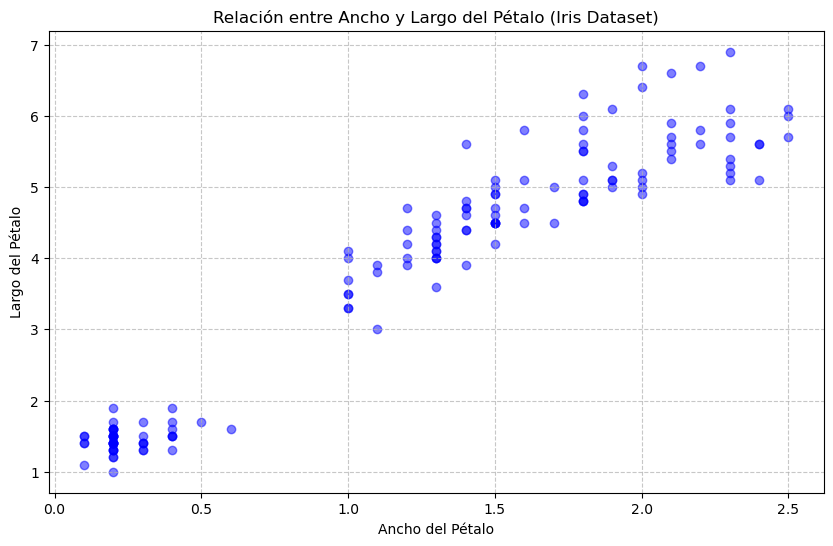

In [6]:
import matplotlib.pyplot as plt

# Generar el gráfico de dispersión utilizando pyplot
plt.figure(figsize=(10, 6))
plt.scatter(df['petal.width'], df['petal.length'], c='blue', alpha=0.5)

plt.title('Relación entre Ancho y Largo del Pétalo (Iris Dataset)')
plt.xlabel('Ancho del Pétalo')
plt.ylabel('Largo del Pétalo')
plt.grid(True, linestyle='--', alpha=0.7)

# Obtener el objeto de ejes actual y asignarlo a la variable 'grafico'
grafico = plt.gca()

# Mostrar el gráfico
plt.show()

## 🔍 Explicación de los Algoritmos

**1. Operaciones Vectoriales en Pandas (Ejercicio 1):**
Al hacer `(df['petal.width'] - mean) / std`, Pandas es lo suficientemente inteligente como para aplicar esta fórmula matemática a **todas las filas al mismo tiempo**, sin necesidad de usar un ciclo `for`. Esto se llama "Vectorización" y es lo que hace que Pandas sea increíblemente rápido con millones de datos.

**2. Visualización (Ejercicio 2):**
Utilizamos `matplotlib.pyplot` (comúnmente importado como `plt`). La función `.scatter(x, y)` dibuja puntos en coordenadas específicas. Ajustamos el tamaño (`figsize`), añadimos transparencia a los puntos (`alpha=0.5`) para ver donde se superponen, y agregamos etiquetas para que el gráfico sea autoexplicativo.

## 🚀 Nivel Pro: Method Chaining (Encadenamiento de Métodos)

El código anterior cumple con la rúbrica perfectamente. Sin embargo, en entornos avanzados de Data Science, tratar de modificar el mismo DataFrame línea por línea (creando `df_filtrado`, luego mutándolo, etc.) puede ser propenso a errores. 

La práctica moderna ("Pandas Idiomático") prefiere el **Method Chaining**: encadenar múltiples operaciones en un solo flujo continuo de transformaciones. Además, utilizamos el enfoque *Orientado a Objetos* para generar nuestros gráficos. 

Veamos cómo se hace:

=== Análisis Pro Ejecutado ===


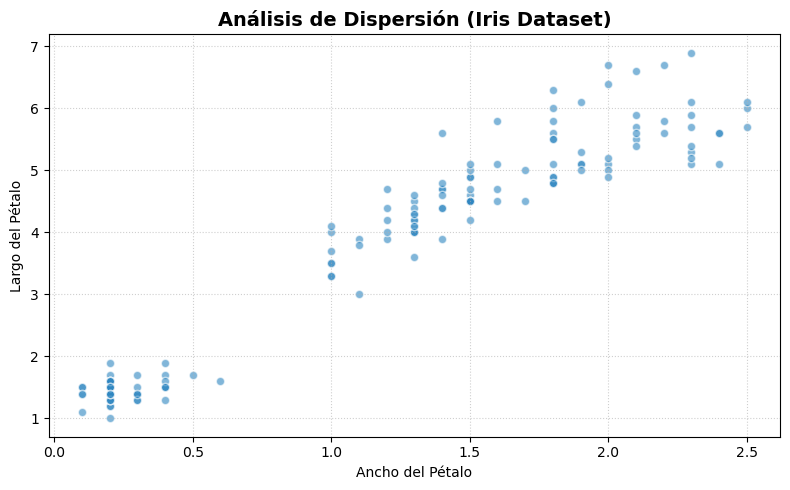

,Variedad,Ancho Est. Pétalo
0,Setosa,-0.500485
5,Setosa,-0.226246
10,Setosa,-0.500485
14,Setosa,-0.500485
15,Setosa,-0.226246


In [7]:
def analizar_iris_pro(url: str):
    """
    Lee, filtra, transforma y agrega estadísticas del dataset Iris 
    utilizando Method Chaining (Código Pandas Idiomático).
    """
    try:
        # 1. Pipeline de Transformación de Datos en un solo bloque
        df_base = pd.read_csv(url)
        
        # Filtramos y estandarizamos en una cadena limpia
        df_limpio = (df_base
             .loc[(df_base['sepal.width'] >= 3.5) & (df_base['sepal.length'] > 5)]
             .assign(
                 # Creamos la columna estandarizada al vuelo
                 petal_width_st=lambda x: (x['petal.width'] - x['petal.width'].mean()) / x['petal.width'].std()
             )
        )
        
        # Generamos el DF final renombrando en el mismo paso
        df_final_pro = (df_limpio
            [['variety', 'petal_width_st']]
            .rename(columns={'variety': 'Variedad', 'petal_width_st': 'Ancho Est. Pétalo'})
        )
        
        # 2. Generación del gráfico Orientado a Objetos (Best Practice)
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.scatter(df_base['petal.width'], df_base['petal.length'], c='#2E86C1', alpha=0.6, edgecolors='w')
        ax.set_title('Análisis de Dispersión (Iris Dataset)', fontsize=14, fontweight='bold')
        ax.set_xlabel('Ancho del Pétalo')
        ax.set_ylabel('Largo del Pétalo')
        ax.grid(True, linestyle=':', alpha=0.6)
        
        plt.tight_layout()
        plt.show()
        
        return df_final_pro.head()
        
    except Exception as e:
        print(f"Error al procesar los datos: {e}")

# Ejecutamos nuestra versión Pro
if __name__ == "__main__":
    print("=== Análisis Pro Ejecutado ===")
    display(analizar_iris_pro(url_iris)) # 'display' renderiza la tabla bonita en Jupyter

## 🔍 Explicación de la Versión Profesional

1. **Method Chaining (`.loc[].assign()`)**: 
   Agrupamos las operaciones entre paréntesis `()`. Esto permite aplicar un método tras otro sin tener que sobrescribir la variable `df` repetidas veces. Es más rápido de leer y consume menos memoria temporal.
2. **El método `.assign()` y funciones lambda**: 
   Nos permite crear columnas al vuelo. La función anónima `lambda x:` garantiza que los cálculos de media y desviación se hagan sobre los datos ya filtrados en el paso anterior, sin mezclar variables.
3. **Matplotlib Orientado a Objetos (`fig, ax = plt.subplots()`)**: 
   En lugar de usar `plt.scatter` (que actúa sobre un lienzo global), creamos un objeto Figura (`fig`) y un objeto Ejes (`ax`). Luego le decimos a los ejes exactamente qué dibujar (`ax.scatter`). Esta es la práctica obligatoria si en el futuro quieres crear *Dashboards* con múltiples gráficos en una sola imagen.

# 🎉 Conclusión del Cuaderno: El Ecosistema de Datos

¡Felicidades por completar este tema fundamental!

Pasar de las listas y diccionarios nativos de Python a las herramientas especializadas como **Pandas y Matplotlib** es el momento en que verdaderamente te conviertes en un analista de datos.

### 🧠 ¿Qué aprendimos hoy?
* **Indexación y Filtrado (`loc`):** Aprendimos a interrogar a nuestros datos buscando condiciones específicas (flores con ciertos tamaños).
* **Agregación (`groupby`):** Comprendimos la filosofía "Dividir, Aplicar y Combinar", esencial para obtener estadísticas descriptivas (Media, Mediana, Desviación).
* **Vectorización:** Descubrimos cómo aplicar matemáticas a toda una columna al instante, evitando los costosos ciclos `for`.
* **Visualización:** Empezamos a traducir números en información visual mediante gráficos de dispersión para hallar correlaciones.
* **Buenas Prácticas:** Introdujimos el *Method Chaining* y la instanciación de gráficos por objetos, estándares absolutos en el código de producción.

## 📚 Glosario de Análisis de Datos con Pandas



Para consolidar tu aprendizaje y tener a la mano la terminología exacta utilizada en la industria de la Ciencia de Datos, aquí tienes los conceptos clave aplicados en este cuaderno:

* **Agregación (Aggregation):** Proceso de resumir un gran volumen de datos aplicando una función estadística (como suma, media, conteo o desviación estándar) a grupos específicos. En Pandas, se logra principalmente con el método `.groupby()`.
* **DataFrame:** Estructura de datos bidimensional, tabular y mutable proporcionada por Pandas. Es el equivalente a una tabla SQL o una hoja de cálculo en Excel, compuesta por filas y columnas.
* **Estandarización (Standardization):** Técnica estadística de transformación de datos que reescala los valores de una variable para observar su desviación respecto a la media. Es un paso crucial en el preprocesamiento para algoritmos de Machine Learning.
* **Extracción / Indexación:** Proceso de seleccionar un subconjunto de datos (filas o columnas específicas) de un DataFrame. Se realiza usando corchetes `[]` para columnas, o métodos como `.loc[]` (por etiquetas) e `.iloc[]` (por posición numérica).
* **Filtrado (Máscaras Booleanas):** Técnica para extraer solo las filas que cumplen con una o más condiciones lógicas (ej. `df[df['columna'] > 5]`).
* **Method Chaining (Encadenamiento de Métodos):** Práctica profesional (Pandas Idiomático) que consiste en invocar múltiples métodos de Pandas secuencialmente en una sola instrucción matemática, evitando la creación innecesaria de variables intermedias.
* **Series:** Estructura de datos unidimensional en Pandas. Si un DataFrame es la tabla completa, una *Series* es una sola columna de esa tabla.
* **Vectorización:** Capacidad de Pandas (heredada de NumPy) para aplicar operaciones matemáticas a columnas enteras de forma simultánea, eliminando la necesidad de usar bucles `for` y mejorando drásticamente la velocidad de procesamiento.